<a href="https://colab.research.google.com/github/Ajithhh0/Ajithhh0/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
# Install required packages
%pip install gliner -q
%pip install pandas tabulate matplotlib seaborn -q

print("✅ Packages installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 29.1 MB/s eta 0:00:00
✅ Packages installed successfully


In [2]:
import time
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from gliner import GLiNER

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

print("✅ Imports done")

✅ Imports done


In [3]:
# ── Test scenarios ────────────────────────────────────────────────────────────

TEST_CASES = {
    "general_news": {
        "text": (
            "Elon Musk, CEO of Tesla and SpaceX, announced on Tuesday that the company "
            "will open a new Gigafactory in Austin, Texas by Q3 2025. "
            "The $5 billion investment was welcomed by Governor Greg Abbott. "
            "Meanwhile, Apple Inc. reported record earnings of $120 billion for fiscal year 2024, "
            "with iPhone sales accounting for 52% of revenue."
        ),
        "labels": ["person", "organization", "location", "date", "money", "product", "percentage"],
    },
    "biomedical": {
        "text": (
            "A 58-year-old female patient presented with stage III non-small cell lung cancer (NSCLC). "
            "She was started on Pembrolizumab 200mg IV every 3 weeks combined with Carboplatin AUC 5. "
            "CT scan showed a 4.2 cm primary tumor in the right upper lobe with mediastinal lymphadenopathy. "
            "EGFR mutation testing was negative; PD-L1 expression was 75%."
        ),
        "labels": ["disease", "drug", "drug_dosage", "drug_frequency", "lab_test", "lab_value", "anatomy", "demographic"],
    },
    "pii_detection": {
        "text": (
            "Please contact John Smith at john.smith@acmecorp.com or call +1 (555) 867-5309. "
            "His SSN is 123-45-6789 and date of birth is March 14, 1985. "
            "His IP address is 192.168.1.104 and his credit card number is 4111 1111 1111 1111."
        ),
        "labels": ["person", "email", "phone_number", "ssn", "date_of_birth", "ip_address", "credit_card"],
    },
    "finance": {
        "text": (
            "Goldman Sachs upgraded NVIDIA (NVDA) to a Buy rating with a price target of $950, "
            "citing strong demand for H100 GPUs from hyperscalers like Microsoft Azure and Google Cloud. "
            "The S&P 500 rose 1.3% on Friday following the Federal Reserve's decision to hold interest rates at 5.25%. "
            "Berkshire Hathaway reported Q2 2024 operating earnings of $11.6 billion."
        ),
        "labels": ["organization", "stock_ticker", "rating", "price_target", "product", "index", "percentage", "date", "money"],
    },
}

print("📋 Test cases loaded:")
for k, v in TEST_CASES.items():
    print(f"  • {k}: {len(v['labels'])} label types")

📋 Test cases loaded:
  • general_news: 7 label types
  • biomedical: 8 label types
  • pii_detection: 7 label types
  • finance: 9 label types


In [4]:
MODELS = [
    {
        "name": "GLiNER Small v2.1",
        "model_id": "urchade/gliner_small-v2.1",
        "family": "Original (urchade)",
        "params": "~50M",
        "multilingual": False,
        "specialty": "General NER",
        "threshold": 0.5,
    },
    {
        "name": "GLiNER Medium v2.1",
        "model_id": "urchade/gliner_medium-v2.1",
        "family": "Original (urchade)",
        "params": "~110M",
        "multilingual": False,
        "specialty": "General NER",
        "threshold": 0.5,
    },
    {
        "name": "GLiNER Large v2.1",
        "model_id": "urchade/gliner_large-v2.1",
        "family": "Original (urchade)",
        "params": "~340M",
        "multilingual": False,
        "specialty": "General NER",
        "threshold": 0.5,
    },
    {
        "name": "GLiNER Multitask Large",
        "model_id": "knowledgator/gliner-multitask-large-v0.5",
        "family": "Multitask (knowledgator)",
        "params": "~340M",
        "multilingual": False,
        "specialty": "NER + Relation + Classification",
        "threshold": 0.5,
    },
    {
        "name": "mGLiNER Small (Multilingual)",
        "model_id": "gliner-community/mgliner-small-v2.1",
        "family": "Multilingual",
        "params": "~117M",
        "multilingual": True,
        "specialty": "100+ languages",
        "threshold": 0.5,
    },
    {
        "name": "NVIDIA GLiNER PII",
        "model_id": "nvidia/gliner-pii",
        "family": "Domain: PII",
        "params": "~340M",
        "multilingual": False,
        "specialty": "PII / PHI Detection",
        "threshold": 0.3,  # recommended by nvidia
    },
    {
        "name": "GLiNER BioMed Base",
        "model_id": "Ihor/gliner-biomed-base-v1.0",
        "family": "Domain: BioMed",
        "params": "~110M",
        "multilingual": False,
        "specialty": "Biomedical NER",
        "threshold": 0.5,
    },
]

print(f"📦 {len(MODELS)} models configured")

📦 7 models configured


In [5]:
import gc
import torch

def run_model(model_cfg: dict, test_cases: dict) -> dict:
    """Load model, run all test cases, collect results."""
    results = {}
    model_id = model_cfg["model_id"]
    threshold = model_cfg["threshold"]

    print(f"\n{'='*60}")
    print(f"🔄 Loading: {model_cfg['name']}")
    print(f"   ID: {model_id}")

    load_start = time.time()
    try:
        model = GLiNER.from_pretrained(model_id)
        load_time = time.time() - load_start
        print(f"   ✅ Loaded in {load_time:.1f}s")
    except Exception as e:
        print(f"   ❌ Failed to load: {e}")
        return None

    for case_name, case_data in test_cases.items():
        text = case_data["text"]
        labels = case_data["labels"]

        infer_start = time.time()
        try:
            entities = model.predict_entities(text, labels, threshold=threshold)
            infer_time = time.time() - infer_start

            results[case_name] = {
                "entities": entities,
                "count": len(entities),
                "infer_time_ms": round(infer_time * 1000),
                "error": None,
            }
            print(f"   📌 {case_name}: {len(entities)} entities | {infer_time*1000:.0f}ms")

        except Exception as e:
            results[case_name] = {"entities": [], "count": 0, "infer_time_ms": None, "error": str(e)}
            print(f"   ⚠️ {case_name}: ERROR — {e}")

    # Free memory
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {"load_time_s": round(load_time, 1), "cases": results}


# ── Run all models ────────────────────────────────────────────────────────────
ALL_RESULTS = {}

for model_cfg in MODELS:
    result = run_model(model_cfg, TEST_CASES)
    if result:
        ALL_RESULTS[model_cfg["name"]] = result

print("\n\n✅ All models evaluated!")


🔄 Loading: GLiNER Small v2.1
   ID: urchade/gliner_small-v2.1


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

   ✅ Loaded in 37.1s
   📌 general_news: 14 entities | 2396ms
   📌 biomedical: 13 entities | 2578ms
   📌 pii_detection: 7 entities | 3197ms
   📌 finance: 16 entities | 6008ms

🔄 Loading: mGLiNER Small (Multilingual)
   ID: gliner-community/mgliner-small-v2.1
   ❌ Failed to load: 401 Client Error. (Request ID: Root=1-69eefed0-3d0d098a6c933c836cddf23f;ae39364c-eaa2-4bbb-aa6a-def7a86b5cee)

Repository Not Found for url: https://huggingface.co/api/models/gliner-community/mgliner-small-v2.1/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

🔄 Loading: NVIDIA GLiNER PII
   ID: nvidia/gliner-pii


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

   ✅ Loaded in 25.4s
   📌 general_news: 14 entities | 2580ms
   📌 biomedical: 10 entities | 2620ms
   📌 pii_detection: 9 entities | 2574ms
   📌 finance: 15 entities | 3576ms

🔄 Loading: GLiNER BioMed Base
   ID: Ihor/gliner-biomed-base-v1.0


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

   ✅ Loaded in 14.4s
   📌 general_news: 15 entities | 740ms
   📌 biomedical: 15 entities | 855ms
   📌 pii_detection: 7 entities | 818ms
   📌 finance: 16 entities | 874ms


✅ All models evaluated!


In [6]:
def display_entities(model_name: str, case_name: str):
    if model_name not in ALL_RESULTS:
        print(f"No results for {model_name}")
        return
    case = ALL_RESULTS[model_name]["cases"].get(case_name, {})
    entities = case.get("entities", [])
    if not entities:
        print(f"No entities found (or error: {case.get('error')})")
        return
    rows = [{"Text": e["text"], "Label": e["label"], "Score": f"{e['score']:.3f}"} for e in entities]
    df = pd.DataFrame(rows)
    print(f"\n📍 {model_name} | Scenario: {case_name} | {len(entities)} entities")
    display(df)


# Show one model × one scenario at a time — cycle through all
for model_cfg in MODELS:
    for case_name in TEST_CASES:
        display_entities(model_cfg["name"], case_name)


📍 GLiNER Small v2.1 | Scenario: general_news | 14 entities


,Text,Label,Score
0,Elon Musk,person,0.975
1,Tesla,organization,0.791
2,SpaceX,organization,0.829
3,Tuesday,date,0.578
4,Gigafactory,location,0.699
5,"Austin, Texas",location,0.860
6,Q3 2025,date,0.934
7,$5 billion,money,0.821
8,Governor Greg Abbott,person,0.817
9,Apple Inc.,organization,0.898



📍 GLiNER Small v2.1 | Scenario: biomedical | 11 entities


,Text,Label,Score
0,58-year-old female patient,demographic,0.825
1,stage III non-small cell lung cancer,disease,0.788
2,NSCLC,disease,0.824
3,Pembrolizumab,drug,0.882
4,every 3 weeks,drug_frequency,0.512
5,Carboplatin,drug,0.824
6,CT scan,lab_test,0.528
7,primary tumor,anatomy,0.502
8,right upper lobe,anatomy,0.893
9,mediastinal lymphadenopathy,anatomy,0.624



📍 GLiNER Small v2.1 | Scenario: pii_detection | 6 entities


...

,Text,Label,Score
0,58-year-old female,demographic,0.912
1,stage III non-small cell lung cancer,disease,0.949
2,NSCLC,disease,0.896
3,Pembrolizumab,drug,0.976
4,200mg,drug_dosage,0.901
5,IV,drug_frequency,0.868
6,every 3 weeks,drug_frequency,0.984
7,Carboplatin,drug,0.919
8,AUC 5,lab_value,0.775
9,CT scan,lab_test,0.964



📍 GLiNER BioMed Base | Scenario: pii_detection | 7 entities


,Text,Label,Score
0,John Smith,person,0.998
1,john.smith@acmecorp.com,email,0.949
2,+1 (555) 867-5309,phone_number,0.988
3,123-45-6789,ssn,0.983
4,"March 14, 1985",date_of_birth,0.995
5,192.168.1.104,ip_address,0.992
6,4111 1111 1111 1111,credit_card,0.974



📍 GLiNER BioMed Base | Scenario: finance | 16 entities


,Text,Label,Score
0,Goldman Sachs,organization,0.993
1,NVIDIA,stock_ticker,0.943
2,NVDA,stock_ticker,0.988
3,Buy,rating,0.985
4,$950,price_target,0.993
5,H100 GPUs,product,0.972
6,Microsoft Azure,organization,0.769
7,Google Cloud,stock_ticker,0.579
8,S&P 500,index,0.993
9,1.3%,percentage,0.995


In [7]:
rows = []

for model_cfg in MODELS:
    name = model_cfg["name"]
    if name not in ALL_RESULTS:
        continue
    res = ALL_RESULTS[name]

    total_entities = sum(v["count"] for v in res["cases"].values())
    avg_infer = [
        v["infer_time_ms"] for v in res["cases"].values() if v["infer_time_ms"] is not None
    ]
    avg_infer_ms = round(sum(avg_infer) / len(avg_infer)) if avg_infer else "N/A"

    case_counts = {case: res["cases"][case]["count"] for case in TEST_CASES}

    rows.append({
        "Model": name,
        "Family": model_cfg["family"],
        "Params": model_cfg["params"],
        "Multilingual": "✅" if model_cfg["multilingual"] else "❌",
        "Specialty": model_cfg["specialty"],
        "Load Time (s)": res["load_time_s"],
        "Avg Infer (ms)": avg_infer_ms,
        "General News": case_counts.get("general_news", "-"),
        "Biomedical": case_counts.get("biomedical", "-"),
        "PII Detection": case_counts.get("pii_detection", "-"),
        "Finance": case_counts.get("finance", "-"),
        "Total Entities": total_entities,
    })

comparison_df = pd.DataFrame(rows)
print("\n📊 GLiNER Model Comparison Table")
print("(Entity counts = number of spans detected per scenario)\n")
display(comparison_df)


📊 GLiNER Model Comparison Table
(Entity counts = number of spans detected per scenario)



,Model,Family,Params,Multilingual,Specialty,Load Time (s),Avg Infer (ms),General News,Biomedical,PII Detection,Finance,Total Entities
0,GLiNER Small v2.1,Original (urchade),~50M,❌,General NER,23.4,1812,14,11,6,10,41
1,GLiNER Medium v2.1,Original (urchade),~110M,❌,General NER,36.0,830,13,14,9,14,50
2,GLiNER Large v2.1,Original (urchade),~340M,❌,General NER,29.8,2840,12,13,7,16,48
3,GLiNER Multitask Large,Multitask (knowledgator),~340M,❌,NER + Relation + Classification,37.1,3545,14,13,7,16,50
4,NVIDIA GLiNER PII,Domain: PII,~340M,❌,PII / PHI Detection,25.4,2838,14,10,9,15,48
5,GLiNER BioMed Base,Domain: BioMed,~110M,❌,Biomedical NER,14.4,822,15,15,7,16,53


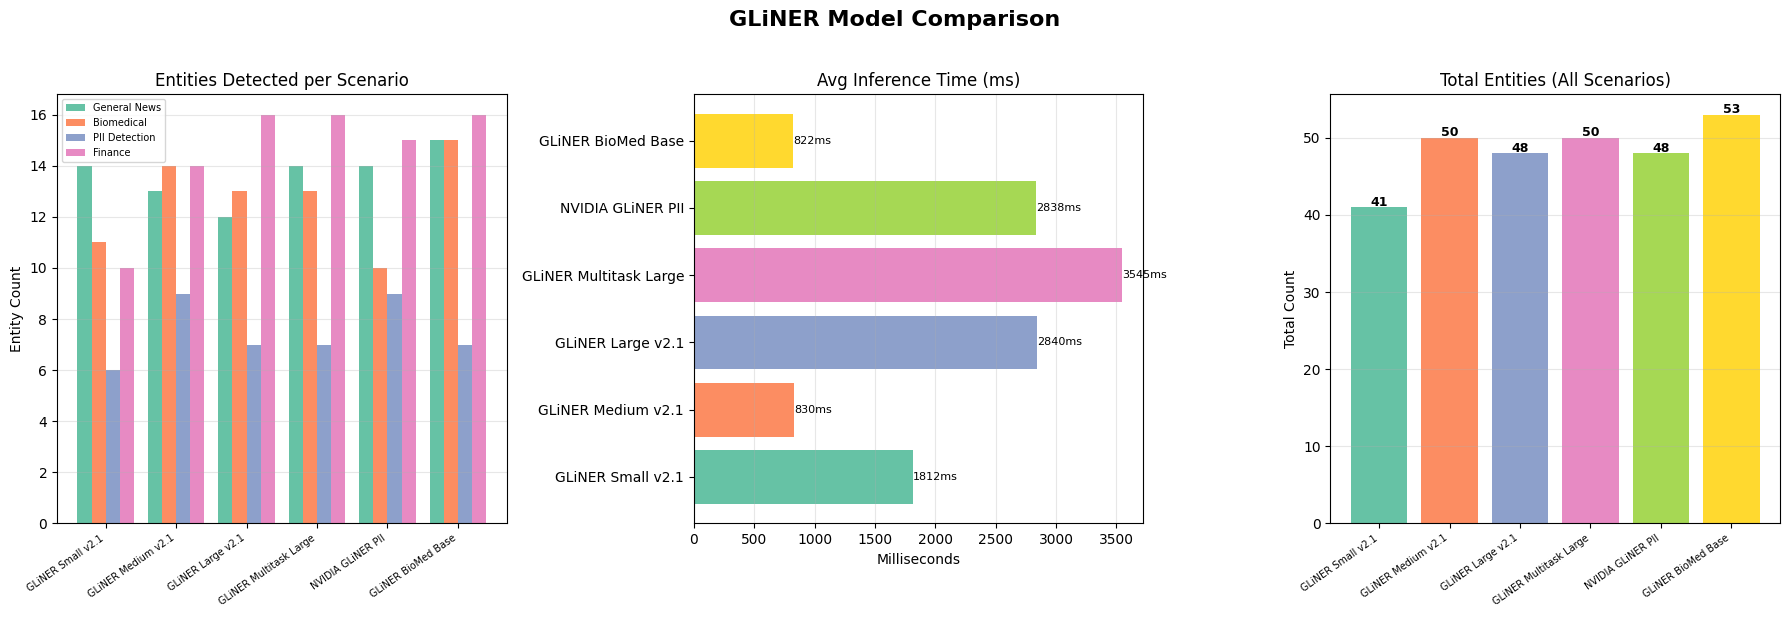

📊 Chart saved as gliner_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("GLiNER Model Comparison", fontsize=16, fontweight="bold", y=1.02)

scenarios = ["General News", "Biomedical", "PII Detection", "Finance"]
model_names = comparison_df["Model"].tolist()
colors = plt.cm.Set2.colors

# ── Plot 1: Entities per scenario (grouped bar) ───────────────────────────────
ax1 = axes[0]
x = range(len(model_names))
bar_w = 0.2
for i, scenario in enumerate(scenarios):
    vals = comparison_df[scenario].tolist()
    ax1.bar([xi + i * bar_w for xi in x], vals, bar_w, label=scenario, color=colors[i])
ax1.set_xticks([xi + bar_w * 1.5 for xi in x])
ax1.set_xticklabels(model_names, rotation=35, ha="right", fontsize=7)
ax1.set_title("Entities Detected per Scenario")
ax1.set_ylabel("Entity Count")
ax1.legend(fontsize=7)
ax1.grid(axis="y", alpha=0.3)

# ── Plot 2: Average inference time ───────────────────────────────────────────
ax2 = axes[1]
infer_vals = [v if isinstance(v, (int, float)) else 0 for v in comparison_df["Avg Infer (ms)"].tolist()]
bars = ax2.barh(model_names, infer_vals, color=[colors[i % len(colors)] for i in range(len(model_names))])
ax2.set_title("Avg Inference Time (ms)")
ax2.set_xlabel("Milliseconds")
ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, infer_vals):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{val}ms",
             va="center", fontsize=8)

# ── Plot 3: Total entities ────────────────────────────────────────────────────
ax3 = axes[2]
total_vals = comparison_df["Total Entities"].tolist()
bars3 = ax3.bar(model_names, total_vals, color=[colors[i % len(colors)] for i in range(len(model_names))])
ax3.set_title("Total Entities (All Scenarios)")
ax3.set_ylabel("Total Count")
ax3.set_xticklabels(model_names, rotation=35, ha="right", fontsize=7)
ax3.grid(axis="y", alpha=0.3)
for bar, val in zip(bars3, total_vals):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, str(val),
             ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("gliner_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved as gliner_comparison.png")

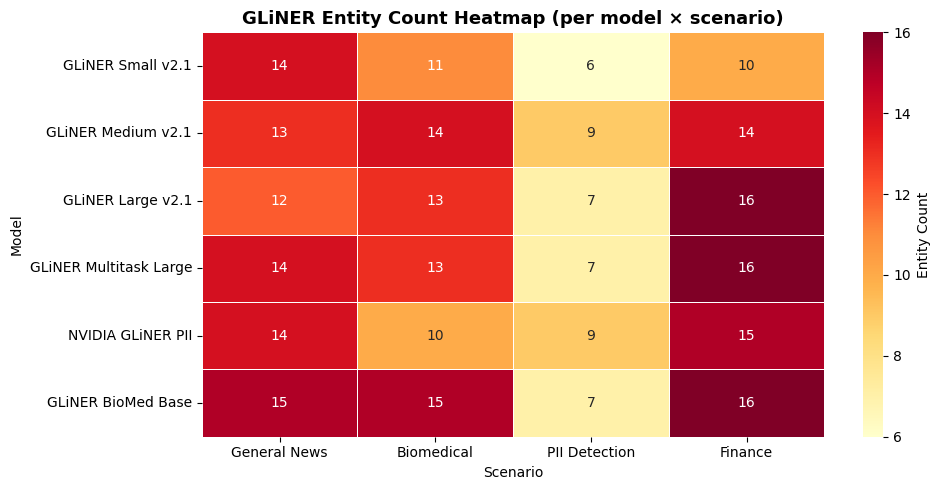

🗺️ Heatmap saved as gliner_heatmap.png


In [9]:
heat_data = comparison_df.set_index("Model")[scenarios]

plt.figure(figsize=(10, 5))
sns.heatmap(
    heat_data,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Entity Count"},
)
plt.title("GLiNER Entity Count Heatmap (per model × scenario)", fontsize=13, fontweight="bold")
plt.ylabel("Model")
plt.xlabel("Scenario")
plt.tight_layout()
plt.savefig("gliner_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("🗺️ Heatmap saved as gliner_heatmap.png")

In [10]:
comparison_df.to_csv("gliner_comparison.csv", index=False)
print("✅ Saved gliner_comparison.csv")
print("\n--- Preview ---")
display(comparison_df[["Model", "Family", "Params", "Specialty", "Avg Infer (ms)", "Total Entities"]])

✅ Saved gliner_comparison.csv

--- Preview ---


,Model,Family,Params,Specialty,Avg Infer (ms),Total Entities
0,GLiNER Small v2.1,Original (urchade),~50M,General NER,1812,41
1,GLiNER Medium v2.1,Original (urchade),~110M,General NER,830,50
2,GLiNER Large v2.1,Original (urchade),~340M,General NER,2840,48
3,GLiNER Multitask Large,Multitask (knowledgator),~340M,NER + Relation + Classification,3545,50
4,NVIDIA GLiNER PII,Domain: PII,~340M,PII / PHI Detection,2838,48
5,GLiNER BioMed Base,Domain: BioMed,~110M,Biomedical NER,822,53


In [11]:
# ── Ground truth annotations (entity: label pairs per scenario) ──────────────
GROUND_TRUTH = {
    "general_news": {
        "Elon Musk": "person", "Tesla": "organization", "SpaceX": "organization",
        "Austin": "location", "Texas": "location", "Greg Abbott": "person",
        "Apple Inc.": "organization", "$5 billion": "money",
        "$120 billion": "money", "iPhone": "product", "52%": "percentage",
    },
    "biomedical": {
        "non-small cell lung cancer": "disease", "NSCLC": "disease",
        "Pembrolizumab": "drug", "200mg": "drug_dosage",
        "every 3 weeks": "drug_frequency", "Carboplatin": "drug",
        "right upper lobe": "anatomy", "EGFR mutation testing": "lab_test",
        "75%": "lab_value", "58-year-old female": "demographic",
    },
    "pii_detection": {
        "John Smith": "person", "john.smith@acmecorp.com": "email",
        "+1 (555) 867-5309": "phone_number", "123-45-6789": "ssn",
        "March 14, 1985": "date_of_birth", "192.168.1.104": "ip_address",
        "4111 1111 1111 1111": "credit_card",
    },
    "finance": {
        "Goldman Sachs": "organization", "NVIDIA": "organization",
        "NVDA": "stock_ticker", "$950": "price_target",
        "Microsoft Azure": "organization", "Google Cloud": "organization",
        "S&P 500": "index", "1.3%": "percentage",
        "Federal Reserve": "organization", "5.25%": "percentage",
        "Berkshire Hathaway": "organization", "$11.6 billion": "money",
    },
}

# ── Metric computation ────────────────────────────────────────────────────────
def compute_metrics(predicted_entities, ground_truth_dict):
    """Compute precision, recall, F1 against ground truth."""
    pred_set = {(e["text"].strip().lower(), e["label"].lower()) for e in predicted_entities}
    gt_set   = {(k.lower(), v.lower()) for k, v in ground_truth_dict.items()}

    tp = len(pred_set & gt_set)
    fp = len(pred_set - gt_set)
    fn = len(gt_set  - pred_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"TP": tp, "FP": fp, "FN": fn,
             "Precision": round(precision, 3), "Recall": round(recall, 3), "F1": round(f1, 3)}

# ── Build accuracy table ──────────────────────────────────────────────────────
acc_rows = []
for model_cfg in MODELS:
    name = model_cfg["name"]
    if name not in ALL_RESULTS: continue
    row = {"Model": name, "Family": model_cfg["family"]}
    f1_scores = []
    for case, gt in GROUND_TRUTH.items():
        preds = ALL_RESULTS[name]["cases"][case]["entities"]
        m = compute_metrics(preds, gt)
        row[f"{case} P"]  = m["Precision"]
        row[f"{case} R"]  = m["Recall"]
        row[f"{case} F1"] = m["F1"]
        f1_scores.append(m["F1"])
    row["Avg F1"] = round(sum(f1_scores) / len(f1_scores), 3)
    acc_rows.append(row)

acc_df = pd.DataFrame(acc_rows)

# ── Display ───────────────────────────────────────────────────────────────────
print("📐 Accuracy Metrics (Precision / Recall / F1 per scenario)\n")

# Colour-coded F1 heatmap on the full table
f1_cols = [c for c in acc_df.columns if "F1" in c]
display(
    acc_df.style
        .background_gradient(subset=f1_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.3f}" for c in acc_df.select_dtypes("float").columns})
        .set_caption("Green = high F1 | Red = low F1")
)

# Compact summary: just Avg F1 ranked
print("\n🏆 Ranking by Avg F1")
display(
    acc_df[["Model", "Avg F1"]]
        .sort_values("Avg F1", ascending=False)
        .reset_index(drop=True)
        .style.bar(subset=["Avg F1"], color="#5DBB8A", vmin=0, vmax=1)
        .format({"Avg F1": "{:.3f}"})
)

📐 Accuracy Metrics (Precision / Recall / F1 per scenario)



,Model,Family,general_news P,general_news R,general_news F1,biomedical P,biomedical R,biomedical F1,pii_detection P,pii_detection R,pii_detection F1,finance P,finance R,finance F1,Avg F1
0,GLiNER Small v2.1,Original (urchade),0.571,0.727,0.640,0.545,0.600,0.571,0.500,0.429,0.462,0.400,0.333,0.364,0.509
1,GLiNER Medium v2.1,Original (urchade),0.538,0.636,0.583,0.429,0.600,0.500,0.667,0.857,0.750,0.500,0.583,0.538,0.593
2,GLiNER Large v2.1,Original (urchade),0.667,0.727,0.696,0.615,0.800,0.696,0.857,0.857,0.857,0.688,0.917,0.786,0.759
3,GLiNER Multitask Large,Multitask (knowledgator),0.714,0.909,0.800,0.615,0.800,0.696,1.000,1.000,1.000,0.688,0.917,0.786,0.821
4,NVIDIA GLiNER PII,Domain: PII,0.786,1.000,0.880,0.700,0.700,0.700,0.714,0.714,0.714,0.600,0.750,0.667,0.740
5,GLiNER BioMed Base,Domain: BioMed,0.733,1.000,0.846,0.600,0.900,0.720,1.000,1.000,1.000,0.625,0.833,0.714,0.820



🏆 Ranking by Avg F1


,Model,Avg F1
0,GLiNER Multitask Large,0.821
1,GLiNER BioMed Base,0.820
2,GLiNER Large v2.1,0.759
3,NVIDIA GLiNER PII,0.740
4,GLiNER Medium v2.1,0.593
5,GLiNER Small v2.1,0.509
